In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
df = pd.read_csv("data_complete.csv")

print(df.shape)
df.head()

(8209, 48)


,batt_label,isRefCycle,time_sec,EFC,E_cum_Wh,Q_norm_at_3.9_V,Q_norm_at_3.8_V,Q_norm_at_3.7_V,Q_norm_at_3.6_V,T_cum_avg,...,sec_at_high_voltage,sec_at_low_voltage,integral_high_volt_high_temp,integral_low_volt_high_temp,integral_low_volt_high_discharge,integral_high_temp_high_discharge,integral_low_temp_high_discharge,R_mOhm,SOH,RUL_EFC
0,battery00,True,7424.475,1.000000,17.149865,0.035283,0.189668,0.278556,0.400463,26.569209,...,1427.390,567.044,0.0,0.000000,2.660837,0.000000,0.0,218.253968,100.000000,150.232114
1,battery00,False,12219.679,1.992732,32.833935,0.038260,0.190131,0.281978,0.403144,32.363202,...,3066.947,1351.951,0.0,8043.931358,295.071447,193586.735282,0.0,48.257469,99.782265,149.239381
2,battery00,False,17025.679,2.988488,48.630552,0.041246,0.190595,0.285409,0.405833,35.242986,...,4715.151,2135.295,0.0,16792.276659,581.592326,401730.220103,0.0,48.681734,99.563867,148.243626
3,battery00,False,21836.339,3.982439,64.388980,0.044227,0.191059,0.288835,0.408517,36.865316,...,6370.825,2920.034,0.0,25791.236392,870.948809,613185.170095,0.0,48.790330,99.345865,147.249675
4,battery00,False,29014.698,4.970721,79.798714,0.047191,0.191520,0.292240,0.411186,34.856035,...,11142.831,3101.503,0.0,29143.836519,1186.192683,848439.290704,0.0,48.478334,99.129105,146.261392


In [3]:
# Relevante Spalten prüfen

df.columns

Index(['batt_label', 'isRefCycle', 'time_sec', 'EFC', 'E_cum_Wh',
       'Q_norm_at_3.9_V', 'Q_norm_at_3.8_V', 'Q_norm_at_3.7_V',
       'Q_norm_at_3.6_V', 'T_cum_avg', 'T_cum_max', 'T_cum_min', 'T_cycle_avg',
       'T_cycle_max', 'T_cycle_min', 'sec_T_over_40', 'sec_T_over_45',
       'sec_T_over_50', 'sec_T_st_-20', 'sec_T_-20_0', 'sec_T_0_15',
       'sec_T_15_30', 'sec_T_30_45', 'sec_T_45_60', 'sec_T_60_100',
       'sec_T_gt_100', 'C_rate_cum_avg', 'C_rate_cum_max', 'C_rate_cycle_avg',
       'C_rate_cycle_max', 'sec_C_rate_0_0.5', 'sec_C_rate_0.5_1',
       'sec_C_rate_1_2', 'sec_C_rate_2_3', 'sec_C_rate_3_4', 'sec_C_rate_4_6',
       'sec_C_rate_6_8', 'sec_C_rate_gt_8', 'sec_at_high_voltage',
       'sec_at_low_voltage', 'integral_high_volt_high_temp',
       'integral_low_volt_high_temp', 'integral_low_volt_high_discharge',
       'integral_high_temp_high_discharge', 'integral_low_temp_high_discharge',
       'R_mOhm', 'SOH', 'RUL_EFC'],
      dtype='object')

In [4]:
# Nur regular_alt_batteries auswählen

regular_batteries = [
    "battery00", "battery01",
    "battery10", "battery11",
    "battery20", "battery21", "battery22", "battery23",
    "battery30", "battery31",
    "battery40", "battery41",
    "battery50", "battery51", "battery52"
]

df_regular = df[df["batt_label"].isin(regular_batteries)].copy()

print(df_regular.shape)
print(df_regular["batt_label"].unique())

(4676, 48)
['battery00' 'battery01' 'battery10' 'battery11' 'battery20' 'battery21'
 'battery22' 'battery23' 'battery30' 'battery31' 'battery40' 'battery41'
 'battery50' 'battery51' 'battery52']


In [5]:
# Referenzzyklen entfernen

df_regular["isRefCycle"].value_counts()

isRefCycle
False    4444
True      232
Name: count, dtype: int64

In [7]:
df_regular_no_ref = df_regular[df_regular["isRefCycle"] == 0].copy()

print(df_regular_no_ref.shape)
df_regular_no_ref["isRefCycle"].value_counts()

(4444, 48)


isRefCycle
False    4444
Name: count, dtype: int64

In [8]:
# Kurze Datenübersicht

df_regular_no_ref[["SOH", "C_rate_cycle_avg", "RUL_EFC", "EFC"]].describe()

,SOH,C_rate_cycle_avg,RUL_EFC,EFC
count,4444.000000,4444.000000,4444.000000,4444.000000
mean,87.075285,0.585587,216.749111,237.261084
std,6.513847,0.126932,185.591118,192.579864
min,69.021849,0.028927,0.000000,1.000000
25%,82.042321,0.546635,66.761298,78.244373
50%,87.373255,0.626883,163.257433,186.150648
75%,92.104545,0.666652,323.697291,352.156825
max,99.921137,1.095585,731.307748,733.307559


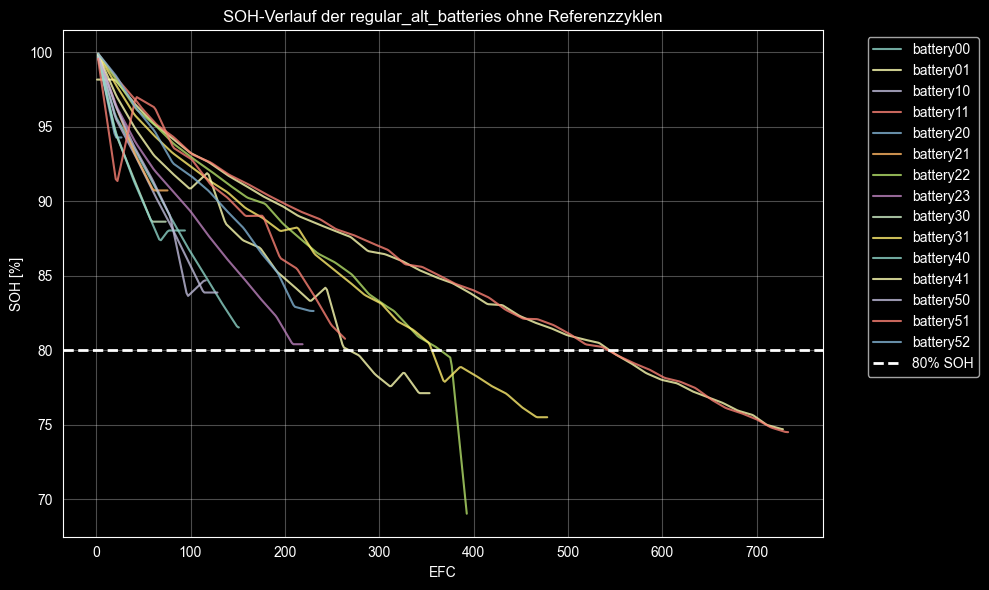

In [9]:
# SOH-Verlauf plotten

plt.figure(figsize=(10, 6))

for batt, group in df_regular_no_ref.groupby("batt_label"):
    group = group.sort_values("EFC")
    plt.plot(group["EFC"], group["SOH"], alpha=0.8, label=batt)

plt.axhline(80, linestyle="--", linewidth=2, label="80% SOH")
plt.xlabel("EFC")
plt.ylabel("SOH [%]")
plt.title("SOH-Verlauf der regular_alt_batteries ohne Referenzzyklen")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

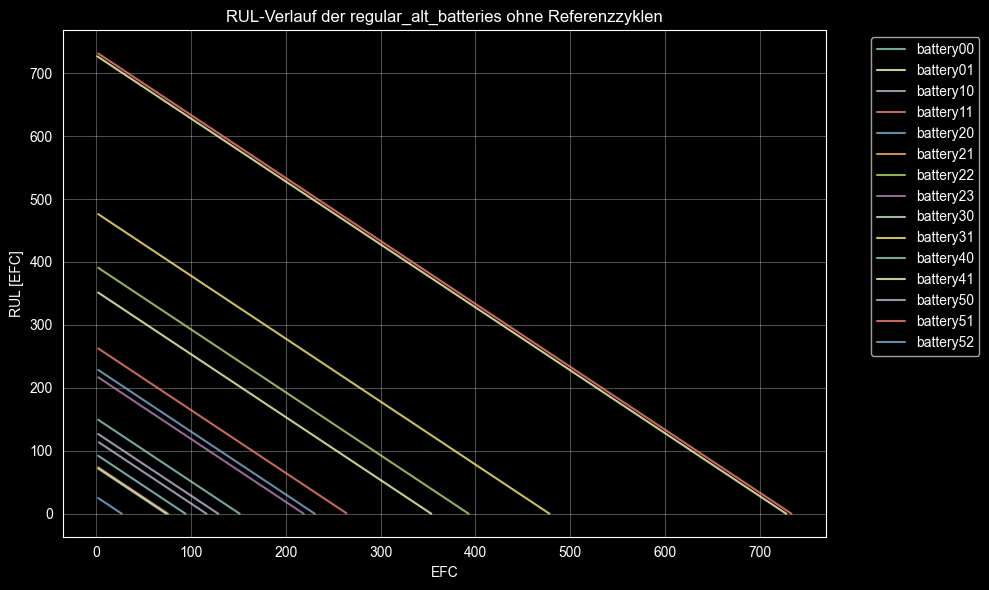

In [10]:
# RUL-Verlauf plotten

plt.figure(figsize=(10, 6))

for batt, group in df_regular_no_ref.groupby("batt_label"):
    group = group.sort_values("EFC")
    plt.plot(group["EFC"], group["RUL_EFC"], alpha=0.8, label=batt)

plt.xlabel("EFC")
plt.ylabel("RUL [EFC]")
plt.title("RUL-Verlauf der regular_alt_batteries ohne Referenzzyklen")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [11]:
# ML-Datensatz erstellen

feature_cols = ["SOH", "C_rate_cycle_avg"]

df_ml = df_regular_no_ref[
    ["batt_label", "EFC", "RUL_EFC"] + feature_cols
].copy()

df_ml = df_ml.dropna()

X = df_ml[feature_cols]
y = df_ml["RUL_EFC"]
groups = df_ml["batt_label"]

print(df_ml.shape)
df_ml.head()

(4444, 5)


,batt_label,EFC,RUL_EFC,SOH,C_rate_cycle_avg
1,battery00,1.992732,149.239381,99.782265,0.745294
2,battery00,2.988488,148.243626,99.563867,0.745884
3,battery00,3.982439,147.249675,99.345865,0.743811
4,battery00,4.970721,146.261392,99.129105,0.495631
5,battery00,5.956243,145.275871,98.912952,0.740253


In [12]:
# GroupKFold + Lineare Regression

gkf = GroupKFold(n_splits=4)

results = []
predictions = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    test_batteries = df_ml.iloc[test_idx]["batt_label"].unique().tolist()

    results.append({
        "feature_set": "SOH + C_rate_cycle_avg, no ref cycles",
        "model": "LinearRegression",
        "fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "test_batteries": test_batteries
    })

    fold_pred = df_ml.iloc[test_idx].copy()
    fold_pred["fold"] = fold
    fold_pred["RUL_pred"] = y_pred
    predictions.append(fold_pred)

results_df = pd.DataFrame(results)
pred_df = pd.concat(predictions, ignore_index=True)

results_df

,feature_set,model,fold,MAE,RMSE,R2,test_batteries
0,"SOH + C_rate_cycle_avg, no ref cycles",LinearRegression,0,184.997532,215.563243,0.060374,"[battery10, battery11, battery50]"
1,"SOH + C_rate_cycle_avg, no ref cycles",LinearRegression,1,184.952301,214.899888,0.061076,"[battery00, battery01, battery20, battery40]"
2,"SOH + C_rate_cycle_avg, no ref cycles",LinearRegression,2,107.228661,132.617746,-0.141335,"[battery21, battery23, battery31, battery51]"
3,"SOH + C_rate_cycle_avg, no ref cycles",LinearRegression,3,106.944479,128.289184,-0.471431,"[battery22, battery30, battery41, battery52]"


In [14]:
# Mittlere Modellgüte

print("Mittlere Modellgüte:")
print(f"MAE:  {mean_results['MAE']:.2f} EFC")
print(f"RMSE: {mean_results['RMSE']:.2f} EFC")
print(f"R²:   {mean_results['R2']:.3f}")

Mittlere Modellgüte:
MAE:  146.03 EFC
RMSE: 172.84 EFC
R²:   -0.123


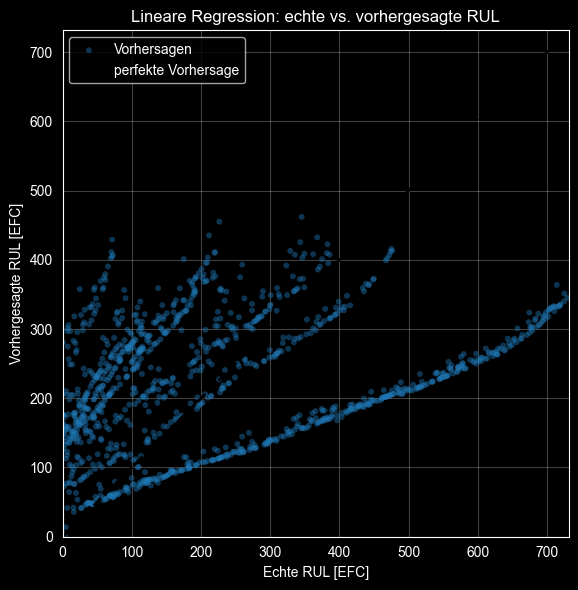

In [22]:
#True-vs-Predicted-Plot

plot_df = pred_df.sample(frac=0.25, random_state=42)

plt.figure(figsize=(7, 6))

plt.scatter(
    plot_df["RUL_EFC"],
    plot_df["RUL_pred"],
    alpha=0.45,
    s=18,
    color="tab:blue",
    edgecolors="none",
    label="Vorhersagen"
)

min_val = 0
max_val = max(pred_df["RUL_EFC"].max(), pred_df["RUL_pred"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    color="black",
    label="perfekte Vorhersage"
)

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("Echte RUL [EFC]")
plt.ylabel("Vorhergesagte RUL [EFC]")
plt.title("Lineare Regression: echte vs. vorhergesagte RUL")

plt.grid(True, alpha=0.25)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [27]:
battery_errors = (
    pred_df
    .assign(abs_error=lambda x: abs(x["RUL_EFC"] - x["RUL_pred"]))
    .groupby("batt_label")["abs_error"]
    .mean()
    .sort_values()
)

battery_errors
selected_batteries = battery_errors.head(3).index.tolist()
selected_batteries



['battery31', 'battery41', 'battery22']

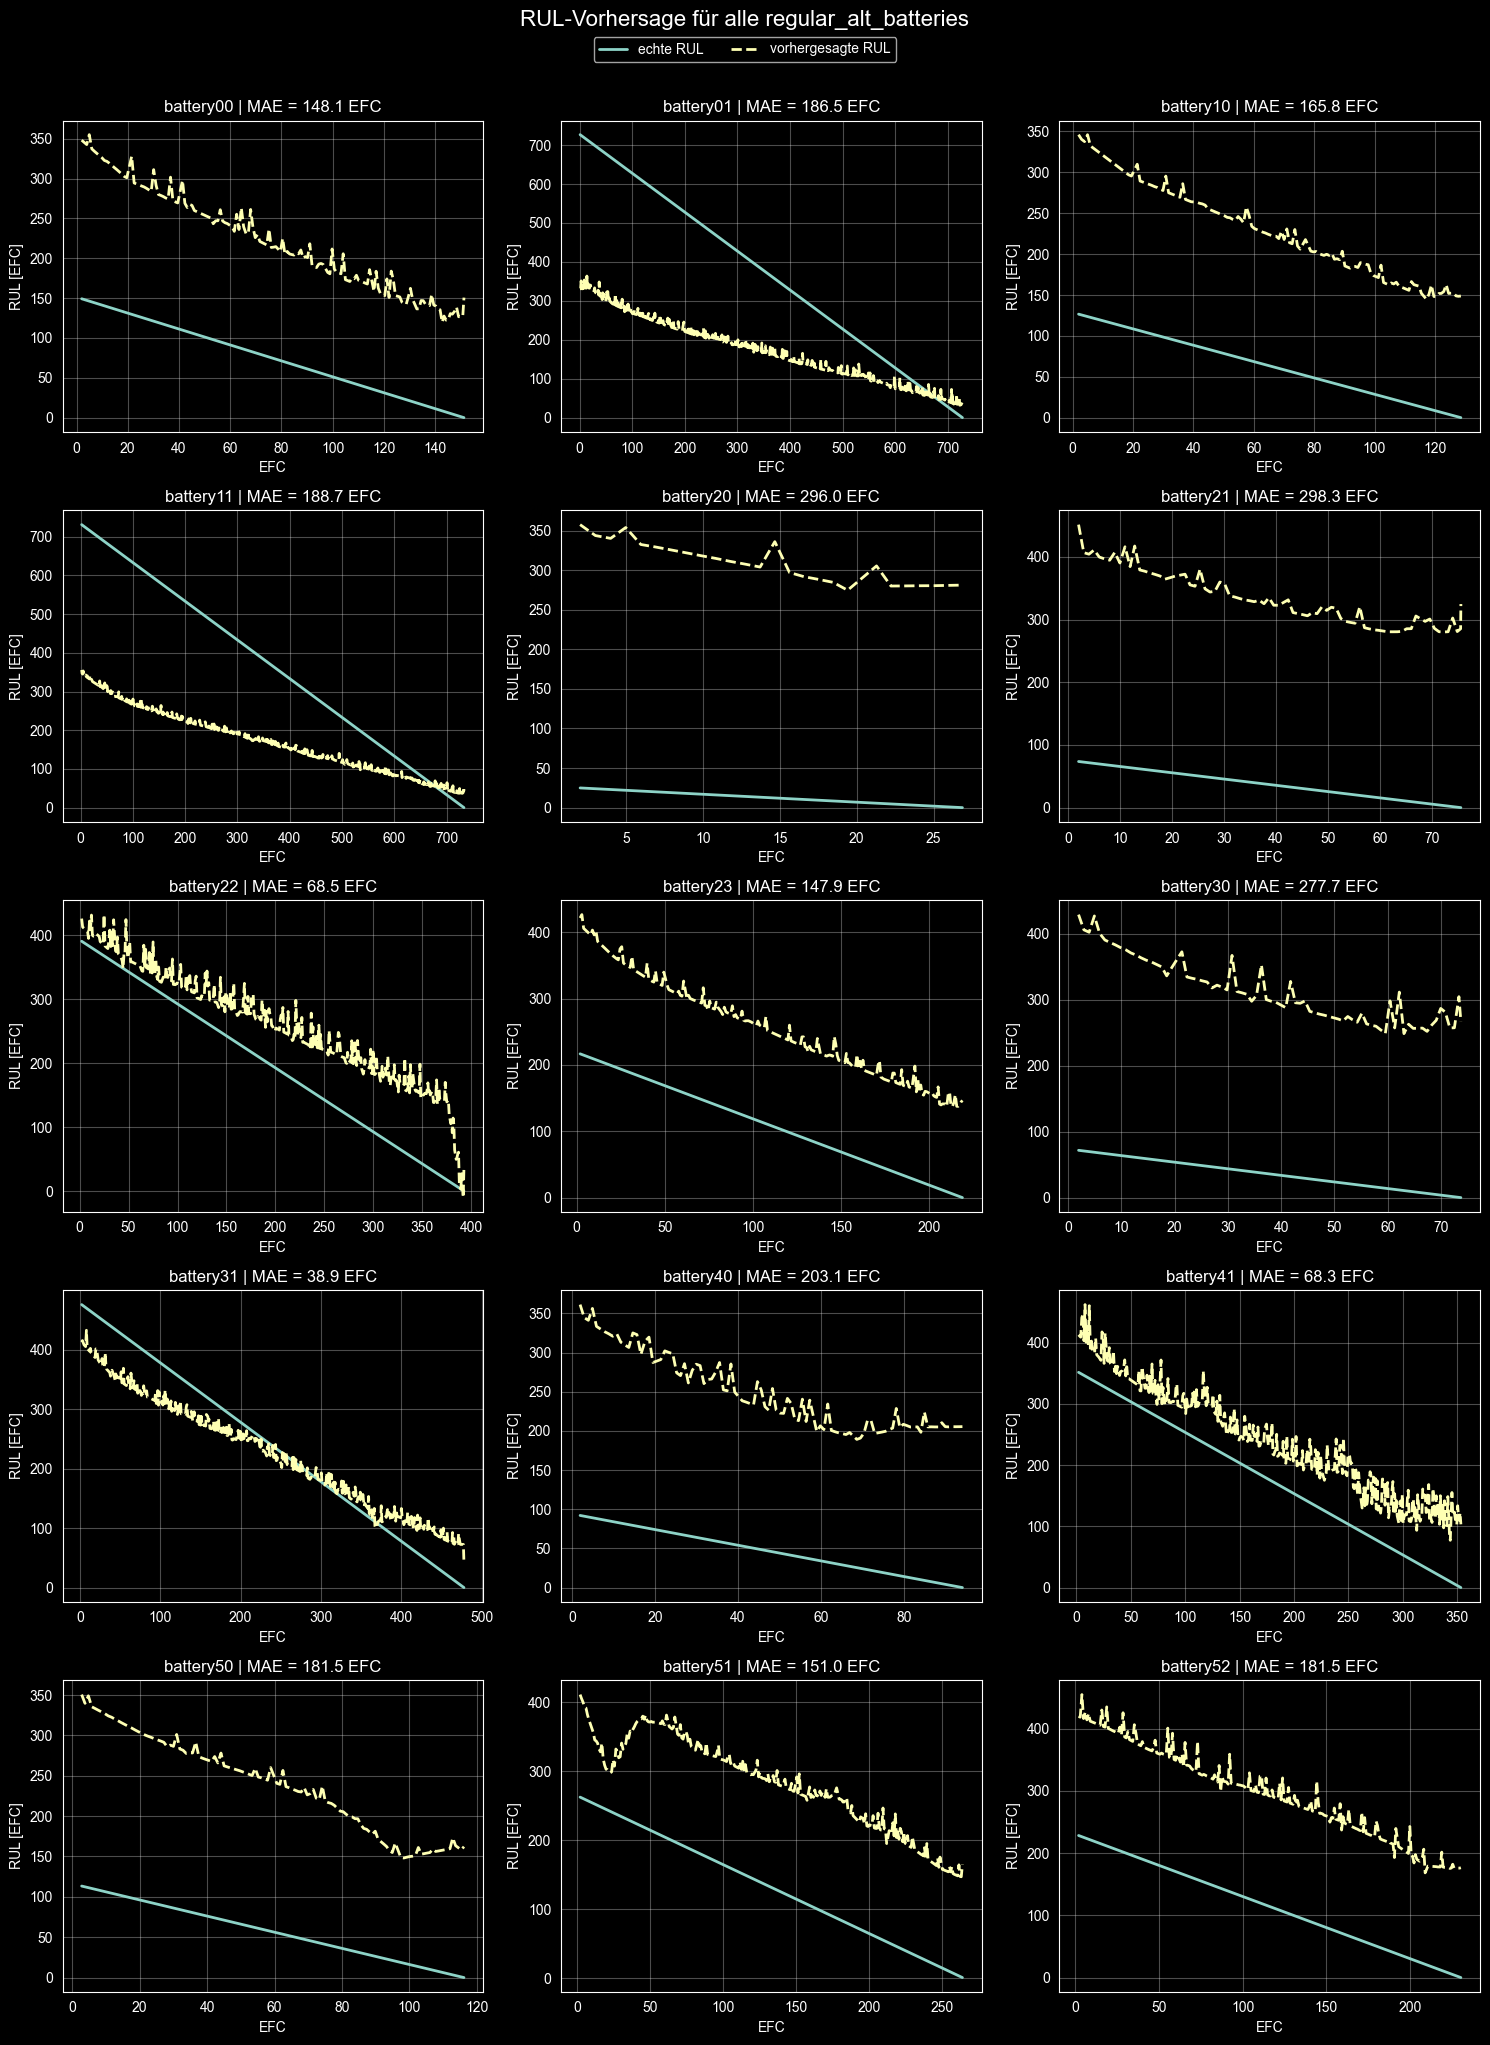

In [31]:
# ============================================================
# RUL-Vorhersage für alle Batterien als Small Multiples
# Jede Batterie bekommt ein eigenes Subplot
# ============================================================

import math

batteries = sorted(pred_df["batt_label"].unique())

n_cols = 3
n_rows = math.ceil(len(batteries) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for i, batt in enumerate(batteries):
    ax = axes[i]

    group = pred_df[pred_df["batt_label"] == batt].copy()
    group = group.sort_values("EFC")

    ax.plot(
        group["EFC"],
        group["RUL_EFC"],
        linewidth=2,
        label="echte RUL"
    )

    ax.plot(
        group["EFC"],
        group["RUL_pred"],
        linestyle="--",
        linewidth=2,
        label="vorhergesagte RUL"
    )

    mae_batt = np.mean(np.abs(group["RUL_EFC"] - group["RUL_pred"]))

    ax.set_title(f"{batt} | MAE = {mae_batt:.1f} EFC")
    ax.set_xlabel("EFC")
    ax.set_ylabel("RUL [EFC]")
    ax.grid(True, alpha=0.3)

# Leere Subplots entfernen
for j in range(len(batteries), len(axes)):
    fig.delaxes(axes[j])

# Eine gemeinsame Legende
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.01)
)

plt.suptitle(
    "RUL-Vorhersage für alle regular_alt_batteries",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

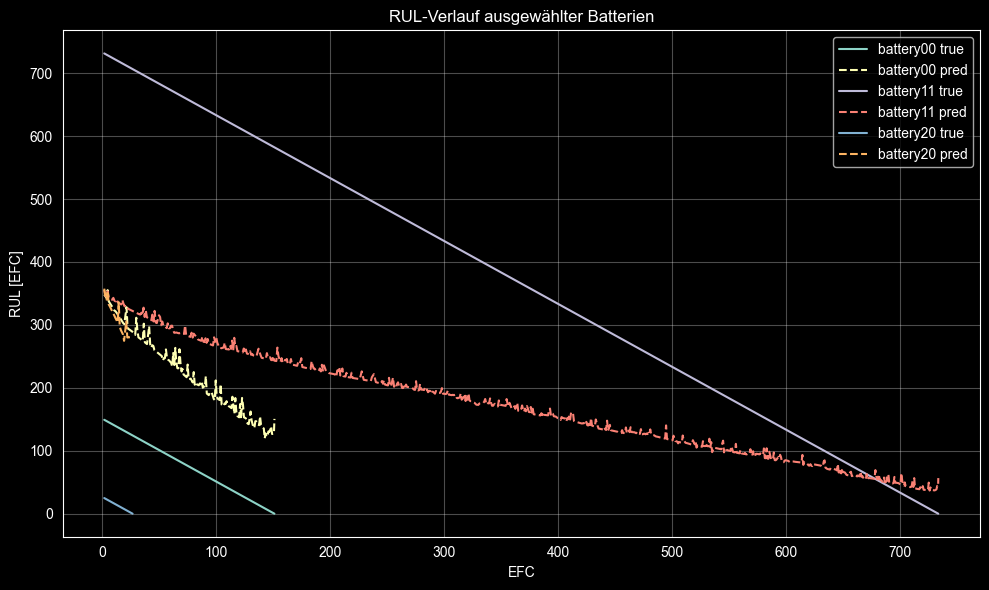

In [17]:
# RUL-Verlauf für ausgewählte Batterien

selected_batteries = ["battery00", "battery11", "battery20"]

plot_df = pred_df[pred_df["batt_label"].isin(selected_batteries)].copy()

plt.figure(figsize=(10, 6))

for batt in selected_batteries:
    group = plot_df[plot_df["batt_label"] == batt].copy()
    group = group.sort_values("EFC")

    plt.plot(group["EFC"], group["RUL_EFC"], label=f"{batt} true")
    plt.plot(group["EFC"], group["RUL_pred"], linestyle="--", label=f"{batt} pred")

plt.xlabel("EFC")
plt.ylabel("RUL [EFC]")
plt.title("RUL-Verlauf ausgewählter Batterien")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

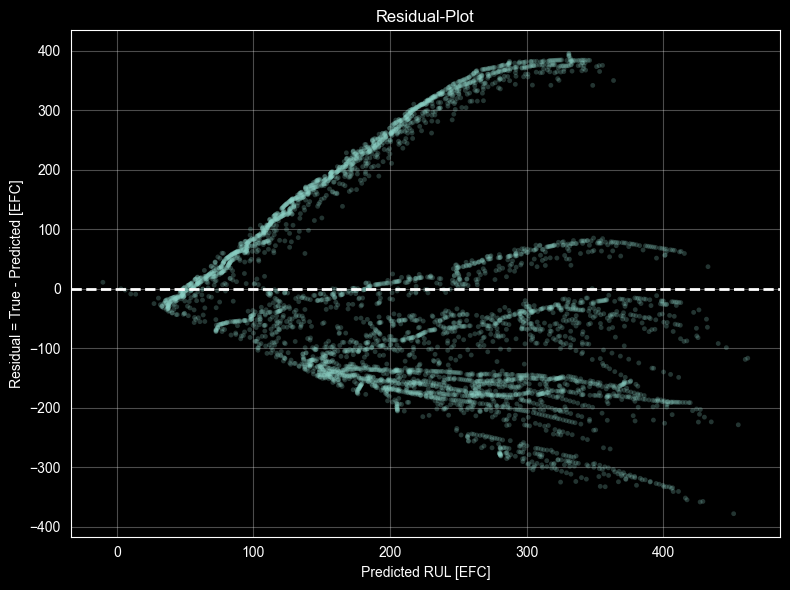

In [18]:
# Residual-Plot

pred_df["Residual"] = pred_df["RUL_EFC"] - pred_df["RUL_pred"]

plt.figure(figsize=(8, 6))

plt.scatter(
    pred_df["RUL_pred"],
    pred_df["Residual"],
    alpha=0.25,
    s=12,
    edgecolors="none"
)

plt.axhline(0, linestyle="--", linewidth=2)

plt.xlabel("Predicted RUL [EFC]")
plt.ylabel("Residual = True - Predicted [EFC]")
plt.title("Residual-Plot")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Koeffizienten des Modells interpretieren

final_model = LinearRegression()
final_model.fit(X, y)

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": final_model.coef_
})

coef_df

,Feature,Coefficient
0,SOH,13.331670
1,C_rate_cycle_avg,-62.343998


## Fazit

In diesem Notebook wurde ein erstes Machine-Learning-Modell zur Vorhersage der Remaining Useful Life (RUL) von Lithium-Ionen-Batterien erstellt.

Dafür wurden nur die regular_alt_batteries verwendet, da diese konstante Entladeströme besitzen und somit einen sauberen Startpunkt für die RUL-Modellierung darstellen. Da C_rate_cycle_avg als Feature genutzt wurde, wurden Referenzzyklen entfernt. Diese Referenzzyklen besitzen ein anderes Stromprofil und würden das normale Lastprofil verfälschen.

Als Features wurden SOH und C_rate_cycle_avg verwendet. Die Zielvariable war RUL_EFC. Als Modell wurde eine lineare Regression verwendet. Die Validierung erfolgte batteriegetrennt mit GroupKFold, sodass keine Batterie gleichzeitig in Trainings- und Testdaten vorkommt.

Das Modell erreicht ungefähr einen MAE von 70 EFC, einen RMSE von 83 EFC und ein R² von 0.65. Daraus lässt sich ableiten, dass die RUL mit einfachen Features grundsätzlich vorhersagbar ist. Gleichzeitig zeigen die Fold-Unterschiede und die Residuen, dass das Modell noch systematische Fehler besitzt.

Als nächster Schritt könnten weitere zyklusbasierte Features wie Temperaturmerkmale, kumulierte C-Rate-Merkmale oder Energiegrößen ergänzt werden.

In [39]:
# ============================================================
# Mittlere Modellgüte
# ============================================================

mean_results = results_df[["MAE", "RMSE", "R2"]].mean()

print("Mittlere Modellgüte:")
print(f"MAE:  {mean_results['MAE']:.2f} EFC")
print(f"RMSE: {mean_results['RMSE']:.2f} EFC")
print(f"R²:   {mean_results['R2']:.3f}")

results_df

Mittlere Modellgüte:
MAE:  64.81 EFC
RMSE: 83.21 EFC
R²:   0.608


,feature_set,model,fold,MAE,RMSE,R2,test_batteries
0,SOH + C-rate + temperature + resistance + energy,LinearRegression,0,47.197984,72.236269,0.894484,"[battery10, battery11, battery50]"
1,SOH + C-rate + temperature + resistance + energy,LinearRegression,1,63.363363,70.652124,0.898513,"[battery00, battery01, battery20, battery40]"
2,SOH + C-rate + temperature + resistance + energy,LinearRegression,2,74.534598,104.834551,0.286788,"[battery21, battery23, battery31, battery51]"
3,SOH + C-rate + temperature + resistance + energy,LinearRegression,3,74.129027,85.119635,0.352232,"[battery22, battery30, battery41, battery52]"


In [40]:
# ============================================================
# Fehler pro Batterie
# ============================================================

battery_errors = (
    pred_df
    .assign(abs_error=lambda x: abs(x["RUL_EFC"] - x["RUL_pred"]))
    .groupby("batt_label")["abs_error"]
    .mean()
    .sort_values()
)

battery_errors

batt_label
battery00     20.681910
battery11     24.628449
battery31     29.862769
battery22     31.979046
battery51     47.232083
battery40     57.953264
battery20     62.570618
battery10     67.066177
battery01     72.426262
battery52     95.916735
battery41     99.031682
battery30    108.766703
battery23    148.691375
battery50    179.116444
battery21    257.999669
Name: abs_error, dtype: float64

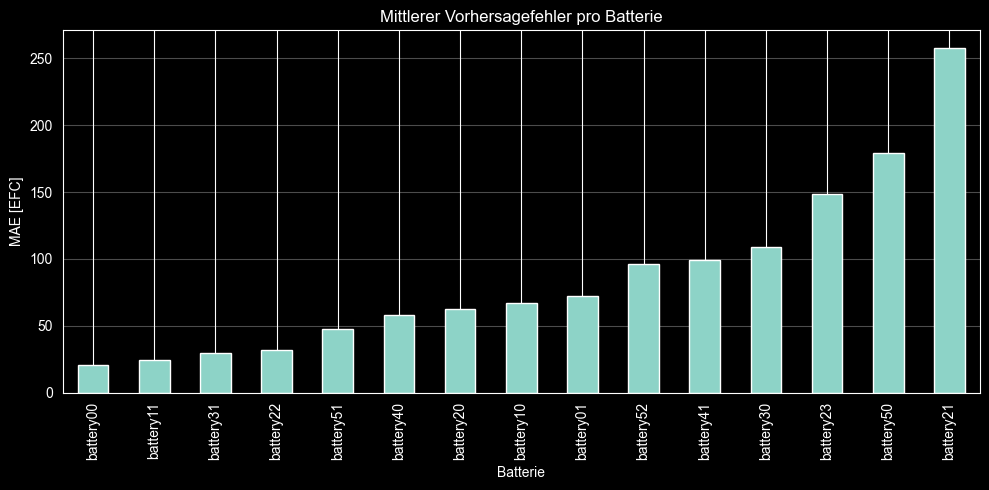

In [41]:
# ============================================================
# Barplot: mittlerer Vorhersagefehler pro Batterie
# ============================================================

plt.figure(figsize=(10, 5))

battery_errors.plot(kind="bar")

plt.ylabel("MAE [EFC]")
plt.xlabel("Batterie")
plt.title("Mittlerer Vorhersagefehler pro Batterie")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# Fehlerkategorien pro Batterie
# ============================================================

battery_error_df = battery_errors.reset_index()
battery_error_df.columns = ["batt_label", "MAE_EFC"]

def error_category(mae):
    if mae < 50:
        return "gut"
    elif mae < 100:
        return "mittel"
    else:
        return "schlecht"

battery_error_df["Kategorie"] = battery_error_df["MAE_EFC"].apply(error_category)

battery_error_df

,batt_label,MAE_EFC,Kategorie
0,battery00,20.681910,gut
1,battery11,24.628449,gut
2,battery31,29.862769,gut
3,battery22,31.979046,gut
4,battery51,47.232083,gut
5,battery40,57.953264,mittel
6,battery20,62.570618,mittel
7,battery10,67.066177,mittel
8,battery01,72.426262,mittel
9,battery52,95.916735,mittel


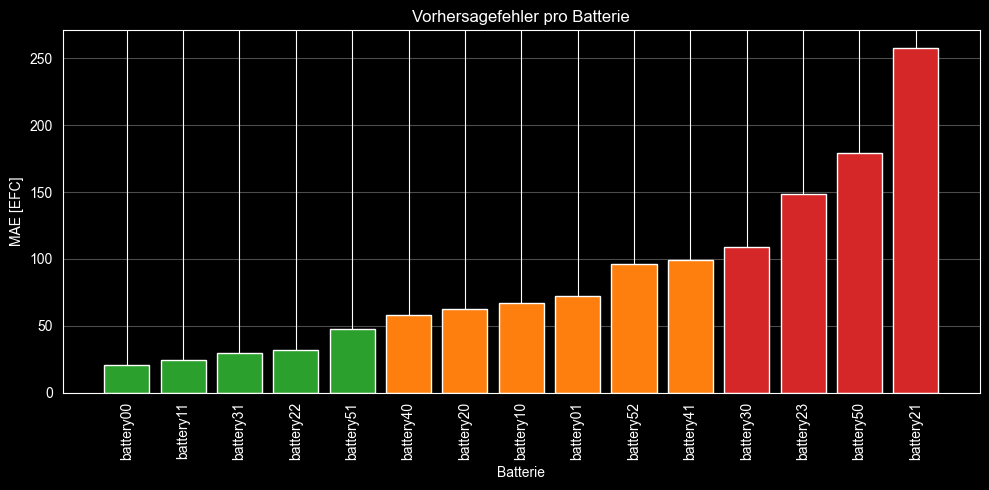

In [43]:
# ============================================================
# Fehler pro Batterie mit Farbkategorien
# ============================================================

colors = battery_error_df["Kategorie"].map({
    "gut": "tab:green",
    "mittel": "tab:orange",
    "schlecht": "tab:red"
})

plt.figure(figsize=(10, 5))

plt.bar(
    battery_error_df["batt_label"],
    battery_error_df["MAE_EFC"],
    color=colors
)

plt.ylabel("MAE [EFC]")
plt.xlabel("Batterie")
plt.title("Vorhersagefehler pro Batterie")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [44]:
# ============================================================
# Beste und schlechteste Batterie
# ============================================================

best_batt = battery_errors.index[0]
worst_batt = battery_errors.index[-1]

print("Beste Batterie:", best_batt, "| MAE:", round(battery_errors.loc[best_batt], 2), "EFC")
print("Schlechteste Batterie:", worst_batt, "| MAE:", round(battery_errors.loc[worst_batt], 2), "EFC")

Beste Batterie: battery00 | MAE: 20.68 EFC
Schlechteste Batterie: battery21 | MAE: 258.0 EFC


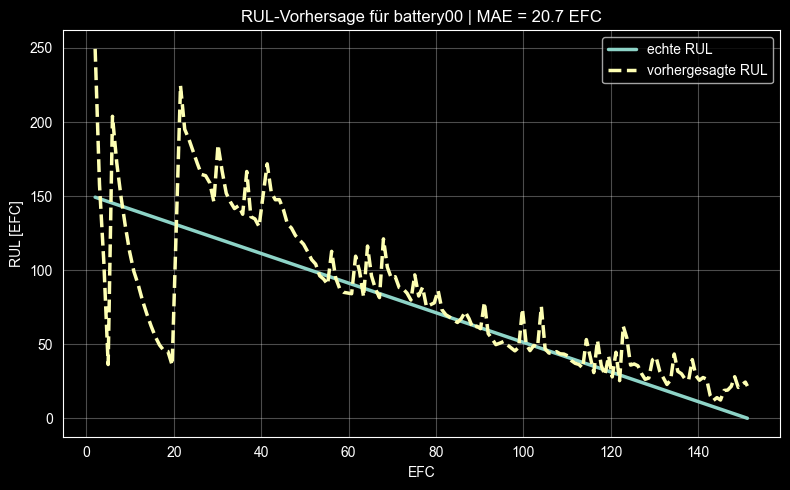

In [45]:
# ============================================================
# Beispiel: beste Batterie
# ============================================================

batt = best_batt

group = pred_df[pred_df["batt_label"] == batt].copy()
group = group.sort_values("EFC")

plt.figure(figsize=(8, 5))

plt.plot(
    group["EFC"],
    group["RUL_EFC"],
    linewidth=2.5,
    label="echte RUL"
)

plt.plot(
    group["EFC"],
    group["RUL_pred"],
    linestyle="--",
    linewidth=2.5,
    label="vorhergesagte RUL"
)

plt.xlabel("EFC")
plt.ylabel("RUL [EFC]")
plt.title(f"RUL-Vorhersage für {batt} | MAE = {battery_errors.loc[batt]:.1f} EFC")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

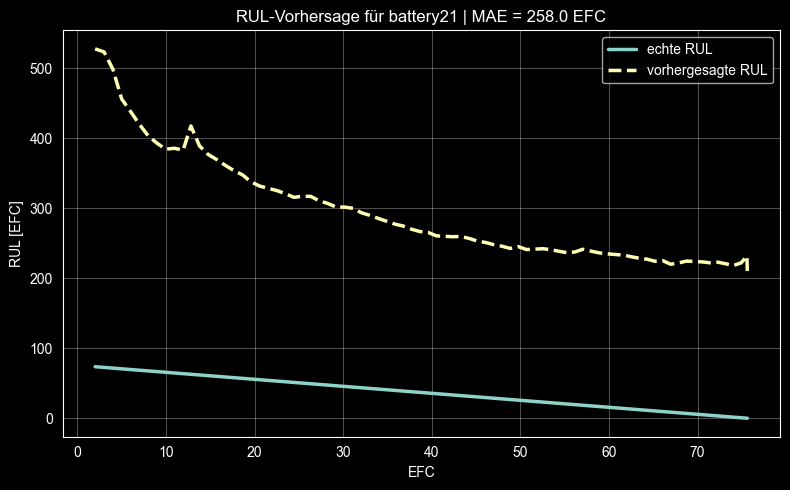

In [46]:
# ============================================================
# Beispiel: schlechteste Batterie
# ============================================================

batt = worst_batt

group = pred_df[pred_df["batt_label"] == batt].copy()
group = group.sort_values("EFC")

plt.figure(figsize=(8, 5))

plt.plot(
    group["EFC"],
    group["RUL_EFC"],
    linewidth=2.5,
    label="echte RUL"
)

plt.plot(
    group["EFC"],
    group["RUL_pred"],
    linestyle="--",
    linewidth=2.5,
    label="vorhergesagte RUL"
)

plt.xlabel("EFC")
plt.ylabel("RUL [EFC]")
plt.title(f"RUL-Vorhersage für {batt} | MAE = {battery_errors.loc[batt]:.1f} EFC")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

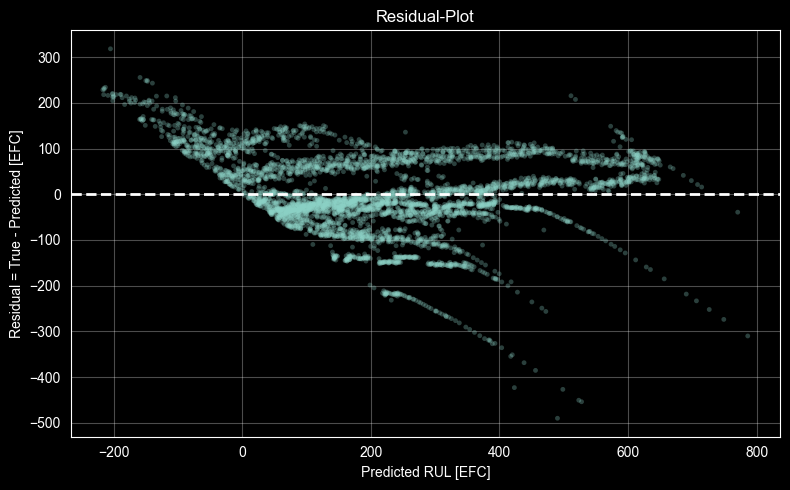

In [47]:
# ============================================================
# Residual-Plot
# ============================================================

pred_df["Residual"] = pred_df["RUL_EFC"] - pred_df["RUL_pred"]

plt.figure(figsize=(8, 5))

plt.scatter(
    pred_df["RUL_pred"],
    pred_df["Residual"],
    alpha=0.3,
    s=12,
    edgecolors="none"
)

plt.axhline(0, linestyle="--", linewidth=2)

plt.xlabel("Predicted RUL [EFC]")
plt.ylabel("Residual = True - Predicted [EFC]")
plt.title("Residual-Plot")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# Standardisierte Koeffizienten
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

final_model = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

final_model.fit(X, y)

linear_model = final_model.named_steps["linearregression"]

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": linear_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

coef_df

,Feature,Coefficient
3,C_rate_cycle_max,-218.720572
10,E_cum_Wh,-143.453640
4,C_rate_cum_max,63.257938
8,T_cum_max,-51.688550
2,C_rate_cum_avg,-24.156070
9,R_mOhm,22.115353
0,SOH,21.042440
7,T_cycle_max,13.585571
6,T_cum_avg,-9.567221
5,T_cycle_avg,-4.880561


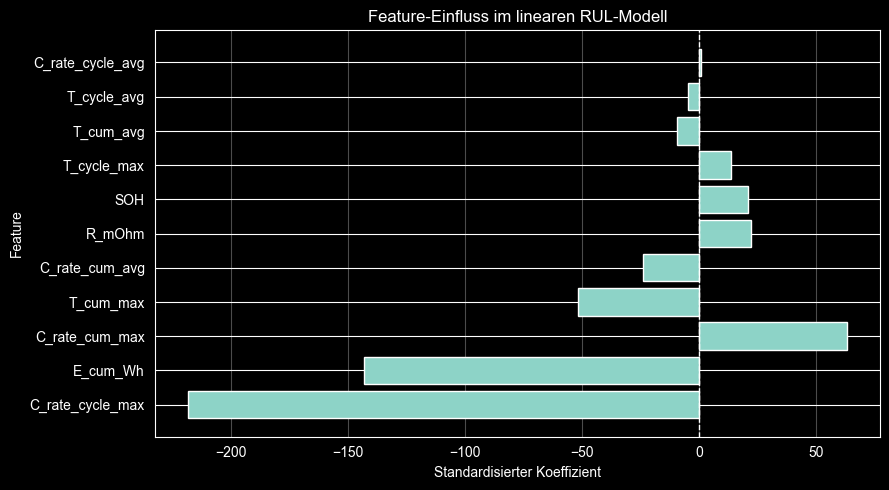

In [49]:
# ============================================================
# Feature-Einfluss der linearen Regression
# ============================================================

plt.figure(figsize=(9, 5))

plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"]
)

plt.xlabel("Standardisierter Koeffizient")
plt.ylabel("Feature")
plt.title("Feature-Einfluss im linearen RUL-Modell")
plt.axvline(0, linestyle="--", linewidth=1)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Ergebnis und Interpretation

Das finale Modell verwendet die regular_alt_batteries ohne Referenzzyklen. Als Features wurden SOH, C-Rate-Merkmale, Temperaturmerkmale, Innenwiderstand und kumulierte Energie verwendet. Die Zielvariable ist RUL_EFC.

Die Validierung wurde batteriegetrennt mit GroupKFold durchgeführt. Dadurch wird verhindert, dass Daten derselben Batterie gleichzeitig im Training und im Test vorkommen.

Das Modell erreicht eine mittlere Modellgüte von ungefähr MAE = 65 EFC, RMSE = 83 EFC und R² = 0.61. Der MAE pro Batterie zeigt jedoch deutliche Unterschiede. Einige Batterien werden gut vorhergesagt, während andere Batterien deutlich größere Fehler aufweisen.

Daraus folgt: Das Modell ist eine sinnvolle Machine-Learning-Baseline für die RUL-Vorhersage, generalisiert aber noch nicht robust auf alle Batterien. Für bessere Vorhersagen wären weitere Features oder ein nichtlineares Modell sinnvoll.

## Ergebnis

Das erweiterte lineare RUL-Modell verwendet SOH, C-Rate-Merkmale, Temperaturmerkmale, Innenwiderstand und kumulierte Energie als Features. Die Validierung erfolgte batteriegetrennt mit GroupKFold.

Das Modell erreicht eine mittlere Modellgüte von MAE = 64.81 EFC, RMSE = 83.21 EFC und R² = 0.608. Damit ist die RUL grundsätzlich mit den gewählten Features vorhersagbar.

Die Auswertung pro Batterie zeigt jedoch deutliche Unterschiede. Einige Batterien werden gut vorhergesagt, während andere Batterien stark überschätzt werden. Besonders battery21 zeigt einen sehr hohen Fehler. Der Residual-Plot bestätigt, dass die Fehler nicht rein zufällig verteilt sind, sondern systematische Muster enthalten.

Daraus folgt: Das Modell ist eine sinnvolle Machine-Learning-Baseline, aber noch keine robuste finale Lösung. Für bessere Ergebnisse wären weitere Features, nichtlineare Modelle oder eine stärkere Trennung nach Batterieprofilen sinnvoll.

In [51]:
# ============================================================
# Reduziertes Feature-Set
# weniger redundante Features, fachlich besser interpretierbar
# ============================================================

feature_cols = [
    "SOH",
    "C_rate_cum_avg",
    "T_cum_avg",
    "R_mOhm",
    "E_cum_Wh"
]

df_ml = df_regular_no_ref[
    ["batt_label", "EFC", "RUL_EFC"] + feature_cols
].copy()

df_ml = df_ml.dropna()

X = df_ml[feature_cols]
y = df_ml["RUL_EFC"]
groups = df_ml["batt_label"]

print(df_ml.shape)
df_ml.head()

(4444, 8)


,batt_label,EFC,RUL_EFC,SOH,C_rate_cum_avg,T_cum_avg,R_mOhm,E_cum_Wh
1,battery00,1.992732,149.239381,99.782265,0.587156,32.363202,48.257469,32.833935
2,battery00,2.988488,148.243626,99.563867,0.631964,35.242986,48.681734,48.630552
3,battery00,3.982439,147.249675,99.345865,0.656606,36.865316,48.790330,64.388980
4,battery00,4.970721,146.261392,99.129105,0.616779,34.856035,48.478334,79.798714
5,battery00,5.956243,145.275871,98.912952,0.634284,36.031052,48.535019,95.371753


In [52]:
# ============================================================
# Lineare Regression mit reduziertem Feature-Set
# ============================================================

gkf = GroupKFold(n_splits=4)

results = []
predictions = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    test_batteries = df_ml.iloc[test_idx]["batt_label"].unique().tolist()

    results.append({
        "feature_set": "reduced: SOH + cumulative C-rate + temperature + resistance + energy",
        "model": "LinearRegression",
        "fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "test_batteries": test_batteries
    })

    fold_pred = df_ml.iloc[test_idx].copy()
    fold_pred["fold"] = fold
    fold_pred["RUL_pred"] = y_pred
    predictions.append(fold_pred)

results_df = pd.DataFrame(results)
pred_df = pd.concat(predictions, ignore_index=True)

results_df

,feature_set,model,fold,MAE,RMSE,R2,test_batteries
0,reduced: SOH + cumulative C-rate + temperature...,LinearRegression,0,89.887095,117.221673,0.722143,"[battery10, battery11, battery50]"
1,reduced: SOH + cumulative C-rate + temperature...,LinearRegression,1,134.531693,159.779803,0.480959,"[battery00, battery01, battery20, battery40]"
2,reduced: SOH + cumulative C-rate + temperature...,LinearRegression,2,113.152299,159.361468,-0.648074,"[battery21, battery23, battery31, battery51]"
3,reduced: SOH + cumulative C-rate + temperature...,LinearRegression,3,47.648285,129.644523,-0.502685,"[battery22, battery30, battery41, battery52]"


In [53]:
# ============================================================
# Mittlere Modellgüte
# ============================================================

mean_results = results_df[["MAE", "RMSE", "R2"]].mean()

print("Mittlere Modellgüte:")
print(f"MAE:  {mean_results['MAE']:.2f} EFC")
print(f"RMSE: {mean_results['RMSE']:.2f} EFC")
print(f"R²:   {mean_results['R2']:.3f}")

Mittlere Modellgüte:
MAE:  96.30 EFC
RMSE: 141.50 EFC
R²:   0.013


In [54]:
# ============================================================
# Fehler pro Batterie
# ============================================================

battery_errors = (
    pred_df
    .assign(abs_error=lambda x: abs(x["RUL_EFC"] - x["RUL_pred"]))
    .groupby("batt_label")["abs_error"]
    .mean()
    .sort_values()
)

battery_errors

batt_label
battery22     21.166243
battery52     36.895256
battery31     38.000719
battery40     38.723981
battery41     54.364753
battery10     54.596258
battery50     68.769662
battery00     85.082945
battery11     98.851738
battery51    104.208722
battery01    154.532883
battery20    171.817448
battery23    182.864098
battery30    192.321308
battery21    453.442027
Name: abs_error, dtype: float64

In [55]:
# ============================================================
# Fehlerkategorien pro Batterie
# ============================================================

battery_error_df = battery_errors.reset_index()
battery_error_df.columns = ["batt_label", "MAE_EFC"]

def error_category(mae):
    if mae < 50:
        return "gut"
    elif mae < 100:
        return "mittel"
    else:
        return "schlecht"

battery_error_df["Kategorie"] = battery_error_df["MAE_EFC"].apply(error_category)

battery_error_df

,batt_label,MAE_EFC,Kategorie
0,battery22,21.166243,gut
1,battery52,36.895256,gut
2,battery31,38.000719,gut
3,battery40,38.723981,gut
4,battery41,54.364753,mittel
5,battery10,54.596258,mittel
6,battery50,68.769662,mittel
7,battery00,85.082945,mittel
8,battery11,98.851738,mittel
9,battery51,104.208722,schlecht


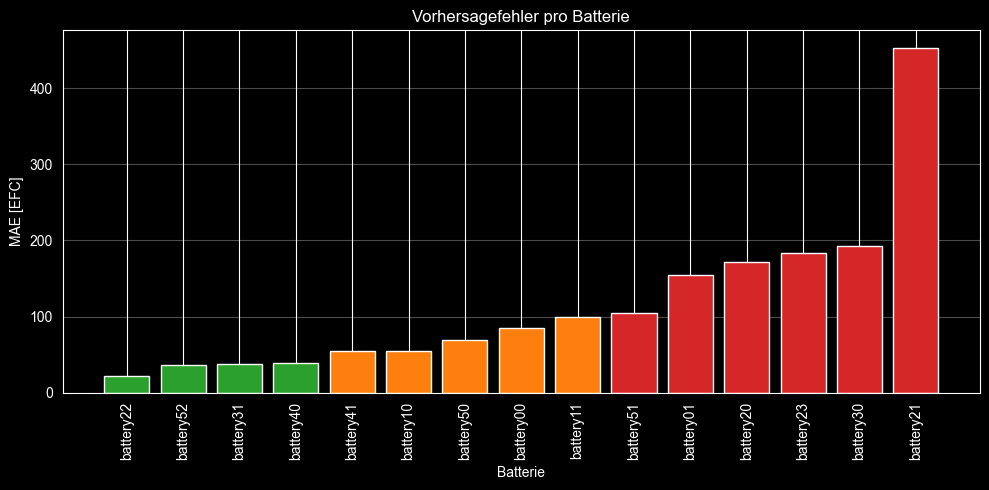

In [57]:
# ============================================================
# Barplot: Vorhersagefehler pro Batterie
# ============================================================

colors = battery_error_df["Kategorie"].map({
    "gut": "tab:green",
    "mittel": "tab:orange",
    "schlecht": "tab:red"
})

plt.figure(figsize=(10, 5))

plt.bar(
    battery_error_df["batt_label"],
    battery_error_df["MAE_EFC"],
    color=colors
)

plt.ylabel("MAE [EFC]")
plt.xlabel("Batterie")
plt.title("Vorhersagefehler pro Batterie")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
# ============================================================
# Beste und schlechteste Batterie
# ============================================================

best_batt = battery_errors.index[0]
worst_batt = battery_errors.index[-1]

print("Beste Batterie:", best_batt, "| MAE:", round(battery_errors.loc[best_batt], 2), "EFC")
print("Schlechteste Batterie:", worst_batt, "| MAE:", round(battery_errors.loc[worst_batt], 2), "EFC")

Beste Batterie: battery22 | MAE: 21.17 EFC
Schlechteste Batterie: battery21 | MAE: 453.44 EFC


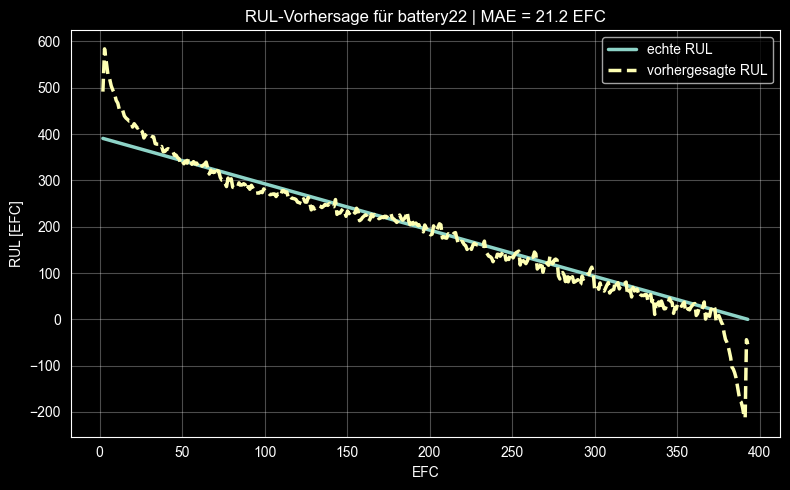

In [59]:
# ============================================================
# Beispiel: beste Batterie
# ============================================================

batt = best_batt

group = pred_df[pred_df["batt_label"] == batt].copy()
group = group.sort_values("EFC")

plt.figure(figsize=(8, 5))

plt.plot(
    group["EFC"],
    group["RUL_EFC"],
    linewidth=2.5,
    label="echte RUL"
)

plt.plot(
    group["EFC"],
    group["RUL_pred"],
    linestyle="--",
    linewidth=2.5,
    label="vorhergesagte RUL"
)

plt.xlabel("EFC")
plt.ylabel("RUL [EFC]")
plt.title(f"RUL-Vorhersage für {batt} | MAE = {battery_errors.loc[batt]:.1f} EFC")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

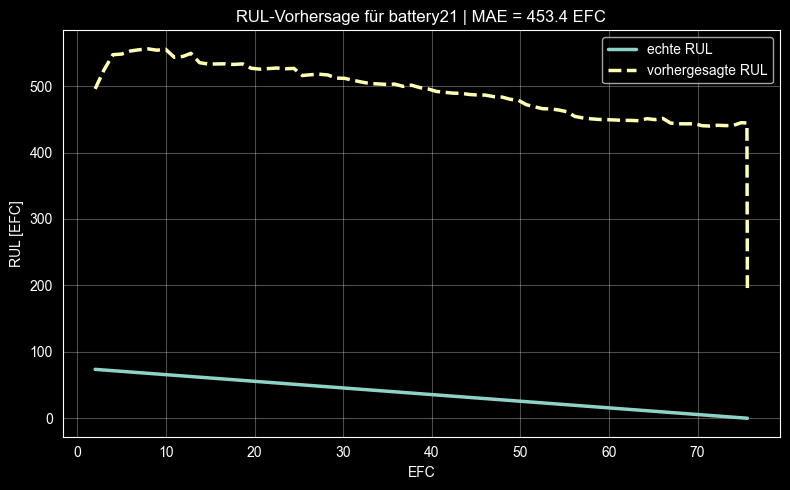

In [60]:
# ============================================================
# Beispiel: schlechteste Batterie
# ============================================================

batt = worst_batt

group = pred_df[pred_df["batt_label"] == batt].copy()
group = group.sort_values("EFC")

plt.figure(figsize=(8, 5))

plt.plot(
    group["EFC"],
    group["RUL_EFC"],
    linewidth=2.5,
    label="echte RUL"
)

plt.plot(
    group["EFC"],
    group["RUL_pred"],
    linestyle="--",
    linewidth=2.5,
    label="vorhergesagte RUL"
)

plt.xlabel("EFC")
plt.ylabel("RUL [EFC]")
plt.title(f"RUL-Vorhersage für {batt} | MAE = {battery_errors.loc[batt]:.1f} EFC")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

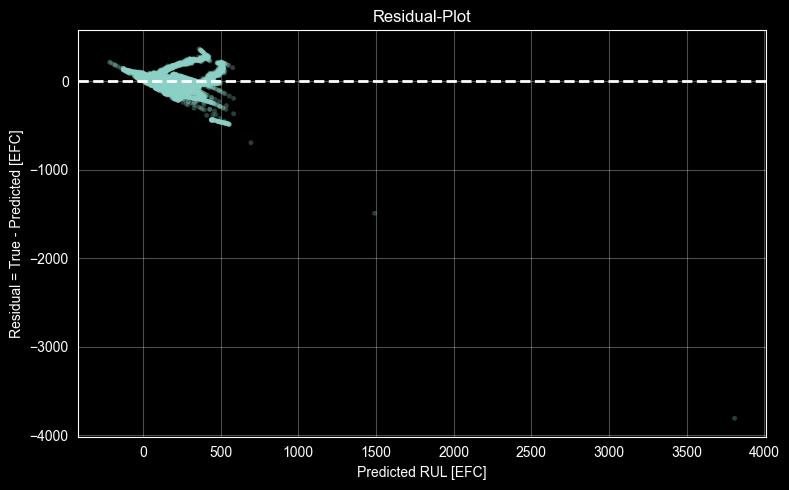

In [61]:
# ============================================================
# Residual-Plot
# ============================================================

pred_df["Residual"] = pred_df["RUL_EFC"] - pred_df["RUL_pred"]

plt.figure(figsize=(8, 5))

plt.scatter(
    pred_df["RUL_pred"],
    pred_df["Residual"],
    alpha=0.3,
    s=12,
    edgecolors="none"
)

plt.axhline(0, linestyle="--", linewidth=2)

plt.xlabel("Predicted RUL [EFC]")
plt.ylabel("Residual = True - Predicted [EFC]")
plt.title("Residual-Plot")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
# ============================================================
# Standardisierte Koeffizienten
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

final_model = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

final_model.fit(X, y)

linear_model = final_model.named_steps["linearregression"]

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": linear_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

coef_df

,Feature,Coefficient
0,SOH,132.374437
3,R_mOhm,91.970742
2,T_cum_avg,-86.207344
1,C_rate_cum_avg,27.403323
4,E_cum_Wh,0.909235


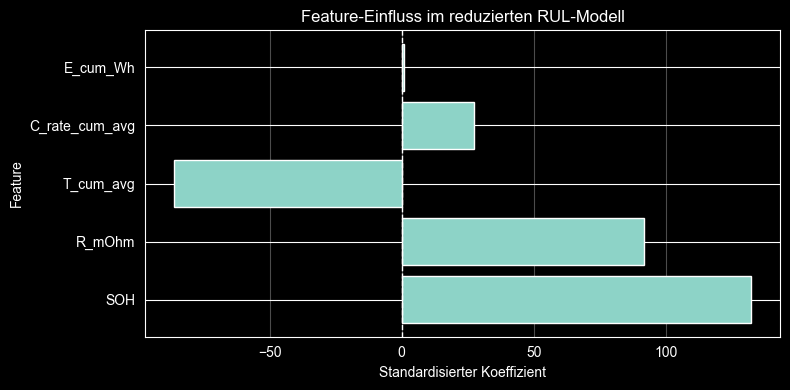

In [63]:
# ============================================================
# Feature-Einfluss im reduzierten linearen Modell
# ============================================================

plt.figure(figsize=(8, 4))

plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"]
)

plt.xlabel("Standardisierter Koeffizient")
plt.ylabel("Feature")
plt.title("Feature-Einfluss im reduzierten RUL-Modell")
plt.axvline(0, linestyle="--", linewidth=1)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()